In [1]:
%cd ..

/data/current/projects/tcrio/tcrio


In [2]:
from tcr_io.filters import Filterer 

In [3]:
from tcr_io.ingestion import DatasetIngester

In [4]:
from tcr_io.mappers import RegexMapper
from pathlib import Path
import polars as pl

In [5]:
from tcr_io.dataset import TcrDataset

In [6]:
ds = TcrDataset(
    "/data/current/tcrio_db/rawat_2026"
)

In [7]:
ds.full_repertoire_meta

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates
str,list[str],str,i64,i64,i64
"""67a2aa4306b40cb07c7a6b2e""","[""67a2aa4306b40cb07c7a6b2e.parquet""]","""221""",134947,13564,246116
"""67a2aa4406b40cb07c7a6b2f""","[""67a2aa4406b40cb07c7a6b2f.parquet""]","""237""",110882,25411,238993
"""67a2aa4406b40cb07c7a6b30""","[""67a2aa4406b40cb07c7a6b30.parquet""]","""391""",89590,11522,165850
"""67a2aa4506b40cb07c7a6b31""","[""67a2aa4506b40cb07c7a6b31.parquet""]","""406""",63361,10646,114782
"""67a2aa4506b40cb07c7a6b32""","[""67a2aa4506b40cb07c7a6b32.parquet""]","""409""",109546,19109,209375
…,…,…,…,…,…
"""67a3d2785c92809cf36a9bfd""","[""67a3d2785c92809cf36a9bfd.parquet""]","""045-896""",101484,9141,183412
"""67a3d2785c92809cf36a9bfe""","[""67a3d2785c92809cf36a9bfe.parquet""]","""045-897""",64290,5574,118612
"""67a3d2795c92809cf36a9bff""","[""67a3d2795c92809cf36a9bff.parquet""]","""045-898""",78368,10025,323613


In [8]:
ds.full_patient_meta

patient_id,patient_repertoires,n_repertoires,age,sex,ethnicity,study_group_description,A,B,C,DRB1,DPA1,DPB1,DQA1,DQB1
str,list[str],i64,f64,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str]
"""221""","[""67a2aa4306b40cb07c7a6b2e""]",1,26.652977,"""female""","""Not Hispanic or Latino""","""AAb- Control""","[""6801"", ""3201""]","[""3906"", ""3508""]","[""0702"", ""0401""]","[""0801""]","[""0103""]","[""0401"", ""0402""]","[""0505"", ""0401""]","[""0301"", ""0402""]"
"""237""","[""67a2aa4406b40cb07c7a6b2f""]",1,28.588638,"""male""","""Not Hispanic or Latino""","""AAb- First Degree Relative""","[""0101"", ""0201""]","[""0801"", ""5701""]","[""0701"", ""0602""]","[""0301"", ""0701""]","[""0103""]","[""0201"", ""0401""]","[""0201"", ""0501""]","[""0201"", ""0303""]"
"""391""","[""67a2aa4406b40cb07c7a6b30""]",1,24.383299,"""male""","""Not Hispanic or Latino""","""AAb- Control""","[""1101"", ""2402""]","[""5201"", ""5401""]","[""1202"", ""0102""]","[""0405"", ""1502""]","[""0202"", ""0201""]","[""0901"", ""0501""]","[""0103"", ""0301""]","[""0401"", ""0601""]"
"""406""","[""67a2aa4506b40cb07c7a6b31""]",1,15.819302,"""male""","""Unknown or Not Reported""","""AAb- First Degree Relative""",null,null,null,null,null,null,null,null
"""409""","[""67a2aa4506b40cb07c7a6b32""]",1,41.730322,"""male""","""Not Hispanic or Latino""","""T1D""",null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""045-896""","[""67a3d2785c92809cf36a9bfd""]",1,42.0,"""female""","""Not Hispanic or Latino""","""T1D""","[""0101"", ""0201""]","[""0801"", ""1501""]","[""0304"", ""0701""]","[""0301"", ""0401""]","[""0103"", ""0201""]","[""0101"", ""0401""]","[""0501""]","[""0201"", ""0301""]"
"""045-897""","[""67a3d2785c92809cf36a9bfe""]",1,34.0,"""female""","""Unknown or Not Reported""","""T1D""","[""0101"", ""0301""]","[""3501"", ""0801""]","[""0401"", ""0701""]","[""0301""]","[""0103""]","[""0401""]","[""0501""]","[""0201""]"
"""045-898""","[""67a3d2795c92809cf36a9bff""]",1,46.0,"""male""","""Not Hispanic or Latino""","""T1D""","[""0101"", ""0201""]","[""1501"", ""0801""]","[""0304"", ""0701""]","[""0301"", ""0401""]","[""0103"", ""0201""]","[""0201"", ""0401""]","[""0501"", ""0301""]","[""0302"", ""0201""]"


In [9]:
from tcr_io.operations import DiversityReport

In [10]:
ds.run_operation(DiversityReport(), force=True)

Computing diversity metrics: 100%|██████████| 2072/2072 [00:10<00:00, 195.80it/s]

Writing DataFrame to /data/current/tcrio_db/rawat_2026/meta/repertoire/diversity_summary.parquet


In [11]:
ds.full_patient_meta

patient_id,patient_repertoires,n_repertoires,age,sex,ethnicity,study_group_description,A,B,C,DRB1,DPA1,DPB1,DQA1,DQB1
str,list[str],i64,f64,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str]
"""221""","[""67a2aa4306b40cb07c7a6b2e""]",1,26.652977,"""female""","""Not Hispanic or Latino""","""AAb- Control""","[""6801"", ""3201""]","[""3906"", ""3508""]","[""0702"", ""0401""]","[""0801""]","[""0103""]","[""0401"", ""0402""]","[""0505"", ""0401""]","[""0301"", ""0402""]"
"""237""","[""67a2aa4406b40cb07c7a6b2f""]",1,28.588638,"""male""","""Not Hispanic or Latino""","""AAb- First Degree Relative""","[""0101"", ""0201""]","[""0801"", ""5701""]","[""0701"", ""0602""]","[""0301"", ""0701""]","[""0103""]","[""0201"", ""0401""]","[""0201"", ""0501""]","[""0201"", ""0303""]"
"""391""","[""67a2aa4406b40cb07c7a6b30""]",1,24.383299,"""male""","""Not Hispanic or Latino""","""AAb- Control""","[""1101"", ""2402""]","[""5201"", ""5401""]","[""1202"", ""0102""]","[""0405"", ""1502""]","[""0202"", ""0201""]","[""0901"", ""0501""]","[""0103"", ""0301""]","[""0401"", ""0601""]"
"""406""","[""67a2aa4506b40cb07c7a6b31""]",1,15.819302,"""male""","""Unknown or Not Reported""","""AAb- First Degree Relative""",null,null,null,null,null,null,null,null
"""409""","[""67a2aa4506b40cb07c7a6b32""]",1,41.730322,"""male""","""Not Hispanic or Latino""","""T1D""",null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""045-896""","[""67a3d2785c92809cf36a9bfd""]",1,42.0,"""female""","""Not Hispanic or Latino""","""T1D""","[""0101"", ""0201""]","[""0801"", ""1501""]","[""0304"", ""0701""]","[""0301"", ""0401""]","[""0103"", ""0201""]","[""0101"", ""0401""]","[""0501""]","[""0201"", ""0301""]"
"""045-897""","[""67a3d2785c92809cf36a9bfe""]",1,34.0,"""female""","""Unknown or Not Reported""","""T1D""","[""0101"", ""0301""]","[""3501"", ""0801""]","[""0401"", ""0701""]","[""0301""]","[""0103""]","[""0401""]","[""0501""]","[""0201""]"
"""045-898""","[""67a3d2795c92809cf36a9bff""]",1,46.0,"""male""","""Not Hispanic or Latino""","""T1D""","[""0101"", ""0201""]","[""1501"", ""0801""]","[""0304"", ""0701""]","[""0301"", ""0401""]","[""0103"", ""0201""]","[""0201"", ""0401""]","[""0501"", ""0301""]","[""0302"", ""0201""]"


In [12]:
div = ds.get_operation_result("diversity_report")

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
div = ds.full_repertoire_meta.join(div, on="repertoire_id")

In [15]:
div = div.join(
    ds.full_patient_meta,
    on="patient_id",
    how="left"
).drop(pl.selectors.by_dtype(pl.List))

In [16]:
div.columns

['repertoire_id',
 'patient_id',
 'n_clonotypes',
 'n_filtered_clonotypes',
 'total_duplicates',
 'observed',
 'd50',
 'shannon_wiener_index',
 'chao1',
 'gini',
 'shannon_wiener',
 'normalized_shannon_wiener',
 'inverse_simpson',
 'gini_simpson',
 'efron_thisted',
 'n_repertoires',
 'age',
 'sex',
 'ethnicity',
 'study_group_description']

In [18]:
from sklearn.linear_model import LinearRegression
# try with feature interactions
from sklearn.preprocessing import PolynomialFeatures

In [19]:
feature_names = ["n_clonotypes","n_filtered_clonotypes","total_duplicates","observed","d50","shannon_wiener_index","chao1","gini","shannon_wiener","normalized_shannon_wiener","inverse_simpson","gini_simpson","efron_thisted"]
X = div[feature_names].to_numpy()
y = div["age"].to_numpy()

In [20]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
# kernelridge:
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

In [22]:
epsilon = 1e-5

In [23]:
X.min()

np.float64(0.05656150074562283)

In [24]:
import numpy as np
from itertools import permutations

def add_pairwise_ratios(X, eps=1e-8):
    n_features = X.shape[1]
    ratio_cols = []
    ratio_names = []
    for i, j in permutations(range(n_features), 2):
        ratio_cols.append((X[:, i] / (X[:, j] + eps)).reshape(-1, 1))
        ratio_names.append(f"x{i}/x{j}")
    return np.hstack([X] + ratio_cols), ratio_names

In [25]:
import numpy as np
# use 5-fold cross-validation, store out-of-fold predictions

kf = KFold(n_splits=6, shuffle=True, random_state=42)
oof_predictions = np.zeros_like(y)
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_log = np.log(X + epsilon)


for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train = poly.fit_transform(X_train)
    X_test = poly.transform(X_test)

    post_poly_scaler = StandardScaler()
    X_train = post_poly_scaler.fit_transform(X_train)
    X_test = post_poly_scaler.transform(X_test)
    
    model = Ridge(alpha=.5)
    model.fit(X_train, y_train)
    
    oof_predictions[test_index] = model.predict(X_test)

mse = mean_squared_error(y, oof_predictions)
mae = np.mean(np.abs(y - oof_predictions))
pearson = np.corrcoef(y, oof_predictions)[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Pearson Correlation: {pearson}")

Mean Squared Error: 173.88085857552338
Mean Absolute Error: 10.08450896455455
Pearson Correlation: 0.6001398729424154


In [34]:
import numpy as np
from itertools import permutations
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error


from sklearn.linear_model import ElasticNet

model = ElasticNet(
    alpha=0.1,         # 1) more regularization (was effectively 0.01 for Lasso)
    l1_ratio=0.5,      # 2) ElasticNet handles correlated features far better than pure Lasso
    max_iter=100000,   # 3) more iterations
    tol=1e-3,          # slightly looser tolerance also helps
)


def make_pairwise_ratios(X, eps=1e-8):
    """Append all ordered pairwise ratios x_i / x_j to X.
    Returns the augmented array and the column names."""
    n_features = X.shape[1]
    cols = [X]
    names = [f"x{i}" for i in range(n_features)]
    for i, j in permutations(range(n_features), 2):
        ratio = X[:, i] / (X[:, j] + eps)
        cols.append(ratio.reshape(-1, 1))
        names.append(f"x{i}/x{j}")
    return np.hstack(cols), names


kf = KFold(n_splits=6, shuffle=True, random_state=42)
oof_predictions = np.zeros_like(y, dtype=float)

# we'll keep the feature names once for inspection later
feature_names = None

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # 1) build pairwise ratios (no learned params here, but kept inside loop for cleanliness)
    X_train, feature_names = make_pairwise_ratios(X_train)
    X_test, _ = make_pairwise_ratios(X_test)


    # # 2) clip extreme ratio values using TRAIN quantiles only (avoids leakage)
    # #    ratios can explode when a denominator is near zero
    # lower = np.quantile(X_train, 0.01, axis=0)
    # upper = np.quantile(X_train, 0.99, axis=0)
    # X_train = np.clip(X_train, lower, upper)
    # X_test = np.clip(X_test, lower, upper)

    # 3) scale (fit on train only)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # 4) Lasso to drive useless ratios to exactly zero
    model.fit(X_train, y_train)

    oof_predictions[test_index] = model.predict(X_test)


mse = mean_squared_error(y, oof_predictions)
mae = np.mean(np.abs(y - oof_predictions))
pearson = np.corrcoef(y, oof_predictions)[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Pearson Correlation: {pearson}")

Mean Squared Error: 159.70564175333038
Mean Absolute Error: 9.987133312206938
Pearson Correlation: 0.6345748601688941


In [37]:
import numpy as np
from itertools import permutations
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error


model = ElasticNet(
    alpha=0.9,         # 1) more regularization (was effectively 0.01 for Lasso)
    l1_ratio=0.5,      # 2) ElasticNet handles correlated features far better than pure Lasso
    max_iter=100000,   # 3) more iterations
    tol=1e-3,          # slightly looser tolerance also helps
)


kf = KFold(n_splits=6, shuffle=True, random_state=42)
oof_predictions = np.zeros_like(y, dtype=float)
feature_names = None

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # 1) pairwise ratios (13 -> 169 features)
    X_train, ratio_names = make_pairwise_ratios(X_train)
    X_test, _ = make_pairwise_ratios(X_test)

    # 2) clip extreme ratios BEFORE squaring them, using train quantiles only.
    #    (squaring an unclipped exploded ratio would be catastrophic)
    lower = np.quantile(X_train, 0.01, axis=0)
    upper = np.quantile(X_train, 0.99, axis=0)
    X_train = np.clip(X_train, lower, upper)
    X_test = np.clip(X_test, lower, upper)

    # 3) polynomial expansion of the ratios (degree=2 -> ~14.5k features)
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
    X_train = poly.fit_transform(X_train)
    X_test = poly.transform(X_test)
    feature_names = poly.get_feature_names_out(ratio_names)

    # 4) scale (fit on train only)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # 5) ElasticNet — strong regularization is now essential
    model.fit(X_train, y_train)

    oof_predictions[test_index] = model.predict(X_test)


mse = mean_squared_error(y, oof_predictions)
mae = np.mean(np.abs(y - oof_predictions))
pearson = np.corrcoef(y, oof_predictions)[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Pearson Correlation: {pearson}")

Mean Squared Error: 158.74438700603136
Mean Absolute Error: 9.979506594098801
Pearson Correlation: 0.6381981700701334


In [38]:
div = div.with_columns(pl.Series("predicted_age", oof_predictions))

In [65]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error


kf = KFold(n_splits=6, shuffle=True, random_state=42)
oof_predictions = np.zeros_like(y, dtype=float)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    X_train, _ = make_pairwise_ratios(X_train)
    X_test, _ = make_pairwise_ratios(X_test)

    model = HistGradientBoostingRegressor(
        learning_rate=0.02,
        max_iter=500,
        max_depth=None,         # let leaves/regularization control complexity
        max_leaf_nodes=10,
        min_samples_leaf=50,
        l2_regularization=0.1,
        early_stopping=True,    # uses an internal validation split
        validation_fraction=0.1,
        random_state=42,
    )
    model.fit(X_train, y_train)

    oof_predictions[test_index] = model.predict(X_test)


mse = mean_squared_error(y, oof_predictions)
mae = np.mean(np.abs(y - oof_predictions))
pearson = np.corrcoef(y, oof_predictions)[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Pearson Correlation: {pearson}")

Mean Squared Error: 164.62952354367047
Mean Absolute Error: 10.162813324645429
Pearson Correlation: 0.6199193554111089


In [87]:
nm = ["n_clonotypes","n_filtered_clonotypes","total_duplicates","observed","d50","shannon_wiener_index","chao1","gini","shannon_wiener","normalized_shannon_wiener","inverse_simpson","gini_simpson","efron_thisted"]

In [88]:
nm[6]

'chao1'

In [89]:
nm[12]

'efron_thisted'

In [86]:
import numpy as np
import lightgbm as lgb
from itertools import permutations
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error


def make_pairwise_ratios(X, eps=1e-8):
    """Append all ordered pairwise ratios x_i / x_j. Returns array + names."""
    n_features = X.shape[1]
    cols = [X]
    names = [f"x{i}" for i in range(n_features)]
    for i, j in permutations(range(n_features), 2):
        ratio = X[:, i] / (X[:, j] + eps)
        cols.append(ratio.reshape(-1, 1))
        names.append(f"x{i}/x{j}")
    return np.hstack(cols), names


kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros_like(y, dtype=float)
feature_names = None
feature_importances = None

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 20,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "n_jobs": -1,
    "verbose": -1,
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # build ratios
    X_train, feature_names = make_pairwise_ratios(X_train)
    X_val, _ = make_pairwise_ratios(X_val)

    # guard against exploded ratios from near-zero denominators,
    # using TRAIN quantiles only
    lower = np.quantile(X_train, 0.001, axis=0)
    upper = np.quantile(X_train, 0.999, axis=0)
    X_train = np.clip(X_train, lower, upper)
    X_val = np.clip(X_val, lower, upper)

    model = lgb.LGBMRegressor(n_estimators=2000, **params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )

    oof_predictions[val_idx] = model.predict(X_val)

    if feature_importances is None:
        feature_importances = np.zeros(len(feature_names))
    feature_importances += model.feature_importances_ / kf.n_splits
    print(f"fold {fold}: best_iter={model.best_iteration_}")


print(f"\nOOF RMSE: {np.sqrt(mean_squared_error(y, oof_predictions)):.5f}")
print(f"OOF R^2:  {r2_score(y, oof_predictions):.5f}")

print("\nTop 20 features (gain-based, averaged over folds):")
order = feature_importances.argsort()[::-1]
for i in order[:20]:
    print(f"  {feature_names[i]:>10}: {feature_importances[i]:.1f}")

mse = mean_squared_error(y, oof_predictions)
mae = np.mean(np.abs(y - oof_predictions))
pearson = np.corrcoef(y, oof_predictions)[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Pearson Correlation: {pearson}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[42]	valid_0's rmse: 13.3397
fold 0: best_iter=42
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[53]	valid_0's rmse: 12.6134
fold 1: best_iter=53
Training until validation scores don't improve for 100 rounds


/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Early stopping, best iteration is:
[40]	valid_0's rmse: 13.0776
fold 2: best_iter=40
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[49]	valid_0's rmse: 12.6016
fold 3: best_iter=49


/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[50]	valid_0's rmse: 12.7984
fold 4: best_iter=50

OOF RMSE: 12.88938
OOF R^2:  0.37863

Top 20 features (gain-based, averaged over folds):
      x6/x12: 78.2
      x12/x6: 45.2
      x0/x12: 30.4
       x0/x2: 28.4
       x4/x8: 26.4
       x2/x6: 24.6
       x5/x7: 24.0
       x4/x6: 22.0
       x1/x7: 21.8
      x2/x12: 21.6
      x4/x12: 21.2
      x1/x10: 20.4
       x1/x6: 20.4
       x0/x6: 20.2
       x6/x8: 19.8
       x1/x8: 19.8
       x1/x4: 19.6
       x1/x2: 19.0
      x1/x12: 17.4
          x6: 17.2
Mean Squared Error: 166.13599088226857
Mean Absolute Error: 10.228852976646714
Pearson Correlation: 0.6155276967988398


/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [98]:
import numpy as np
import lightgbm as lgb
from itertools import combinations
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error


def make_log_ratios(X, eps=1e-8):
    """Append all log-ratios log(x_i / x_j) for i < j.
    Antisymmetric, so we only need combinations (78 instead of 156).
    Returns augmented array + names."""
    n_features = X.shape[1]
    cols = [X]
    names = [f"x{i}" for i in range(n_features)]
    for i, j in combinations(range(n_features), 2):
        log_ratio = np.log(X[:, i] + eps) - np.log(X[:, j] + eps)
        cols.append(log_ratio.reshape(-1, 1))
        names.append(f"log(x{i}/x{j})")
    return np.hstack(cols), names


# sanity check: logs require positive inputs
if np.any(X <= 0):
    n_bad = np.sum(X <= 0)
    print(f"WARNING: {n_bad} non-positive values in X; "
          f"eps guards against -inf but results near zero may be unreliable.")


kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros_like(y, dtype=float)
feature_names = None
feature_importances = None

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 20,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "n_jobs": -1,
    "verbose": -1,
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train, feature_names = make_log_ratios(X_train)
    X_val, _ = make_log_ratios(X_val)

    # log-ratios are already well-behaved, but a gentle clip still guards
    # against extreme tails, using TRAIN quantiles only
    lower = np.quantile(X_train, 0.001, axis=0)
    upper = np.quantile(X_train, 0.999, axis=0)
    X_train = np.clip(X_train, lower, upper)
    X_val = np.clip(X_val, lower, upper)

    model = lgb.LGBMRegressor(n_estimators=2000, **params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )

    oof_predictions[val_idx] = model.predict(X_val)

    if feature_importances is None:
        feature_importances = np.zeros(len(feature_names))
    feature_importances += model.feature_importances_ / kf.n_splits
    print(f"fold {fold}: best_iter={model.best_iteration_}")


print(f"\nOOF RMSE: {np.sqrt(mean_squared_error(y, oof_predictions)):.5f}")
print(f"OOF R^2:  {r2_score(y, oof_predictions):.5f}")

print("\nTop 20 features (gain-based, averaged over folds):")
order = feature_importances.argsort()[::-1]
for i in order[:20]:
    print(f"  {feature_names[i]:>16}: {feature_importances[i]:.1f}")

mse = mean_squared_error(y, oof_predictions)
mae = np.mean(np.abs(y - oof_predictions))
pearson = np.corrcoef(y, oof_predictions)[0, 1]
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Pearson Correlation: {pearson}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[36]	valid_0's rmse: 13.3295
fold 0: best_iter=36
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[39]	valid_0's rmse: 12.6526
fold 1: best_iter=39
Training until validation scores don't improve for 100 rounds


/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Early stopping, best iteration is:
[53]	valid_0's rmse: 13.0888
fold 2: best_iter=53
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[49]	valid_0's rmse: 12.5894
fold 3: best_iter=49
Training until validation scores don't improve for 100 rounds


/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Early stopping, best iteration is:
[37]	valid_0's rmse: 12.8442
fold 4: best_iter=37

OOF RMSE: 12.90395
OOF R^2:  0.37722

Top 20 features (gain-based, averaged over folds):
       log(x6/x12): 101.2
        log(x5/x7): 38.6
        log(x2/x6): 34.8
        log(x0/x6): 32.8
        log(x4/x8): 30.0
       log(x0/x12): 29.8
        log(x0/x2): 29.4
        log(x4/x6): 29.0
       log(x1/x10): 28.2
        log(x1/x7): 26.6
        log(x1/x6): 26.4
        log(x1/x4): 25.4
       log(x4/x12): 24.6
        log(x0/x4): 23.4
                x1: 23.4
       log(x1/x12): 23.2
        log(x6/x8): 23.2
        log(x1/x2): 22.2
        log(x2/x7): 21.6
        log(x4/x7): 21.2
Mean Squared Error: 166.51181878247232
Mean Absolute Error: 10.272867227443237
Pearson Correlation: 0.6150508850238066


/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<Axes: xlabel='age', ylabel='predicted_age'>

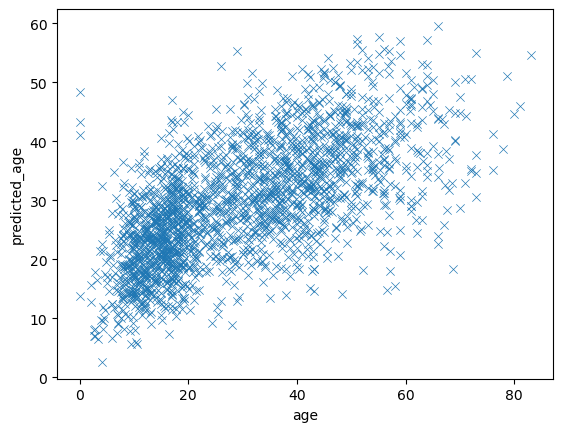

In [78]:
sns.scatterplot(
    data = div, 
    x="age",
    y="predicted_age",
    marker="x"
)

In [156]:
model.feature_names_in_ = feature_names

In [162]:
dict(zip(
    model.feature_names_in_, 
    model.coef_
))

{'n_clonotypes': np.float64(8.733153104808427),
 'n_filtered_clonotypes': np.float64(0.5496652049321473),
 'total_duplicates': np.float64(-9.540631105282191),
 'observed': np.float64(8.73315310480846),
 'd50': np.float64(-6.919137988713947),
 'shannon_wiener_index': np.float64(-0.1574287718957775),
 'chao1': np.float64(-0.4030882986353724),
 'gini': np.float64(3.3626226572330475),
 'shannon_wiener': np.float64(-0.28325114811266094),
 'normalized_shannon_wiener': np.float64(2.7989261041261027),
 'inverse_simpson': np.float64(-0.6307881050170395),
 'gini_simpson': np.float64(-0.3739845324336086),
 'efron_thisted': np.float64(-1.0099590313294518)}

In [ ]:
import polars as pl
import numpy as np
from scipy.special import binom


def compute_metrics(lf: pl.LazyFrame) -> pl.DataFrame:
    """All diversity metrics, single repertoire, pre-sorted desc by duplicate_count."""

    c = pl.col("c")

    result = (
        lf
        .select(pl.col("duplicate_count").cast(pl.Float64).alias("c"))
        .select(
            pl.len().cast(pl.Float64).alias("observed"),

            (c == 1.0).sum().cast(pl.Float64).alias("_f1"),
            (c == 2.0).sum().cast(pl.Float64).alias("_f2"),

            c.sum().alias("_total"),
            (c * c.log()).sum().alias("_sum_c_ln_c"),
            c.pow(2).sum().alias("_sum_c2"),

            (
                pl.when(pl.len() > 0).then(c.cum_sum().le(c.sum() * 0.5).sum() + 1)
                .otherwise(0)
            ).cast(pl.Float64).alias("d50"),

            c.cum_sum().sum().alias("_rank_c_sum"),

            *[
                (c == float(y)).sum().cast(pl.Float64).alias(f"_nx_{y}")
                for y in range(1, 21)
            ],
        )
        .with_columns(
            (pl.col("_total").log() - pl.col("_sum_c_ln_c") / pl.col("_total"))
            .alias("shannon_wiener_index"),

            (pl.col("observed")
             + pl.col("_f1") * (pl.col("_f1") - 1) / (2.0 * (pl.col("_f2") + 1)))
            .alias("chao1"),

            (pl.col("_sum_c2") / pl.col("_total").pow(2)).alias("_sum_p2"),

            (2.0 * pl.col("_rank_c_sum") / (pl.col("observed") * pl.col("_total"))
             - (pl.col("observed") + 1.0) / pl.col("observed"))
            .alias("gini"),
        )
        .with_columns(
            pl.col("shannon_wiener_index").exp().alias("shannon_wiener"),

            (pl.when(pl.col("observed") > 1)
             .then(pl.col("shannon_wiener_index") / pl.col("observed").log())
             .otherwise(0.0))
            .alias("normalized_shannon_wiener"),

            (1.0 / pl.col("_sum_p2")).alias("inverse_simpson"),
            (1.0 - pl.col("_sum_p2")).alias("gini_simpson"),
        )
        .collect()
    )

    nx = result.select([f"_nx_{y}" for y in range(1, 21)]).row(0)
    obs = result["observed"][0]
    ef = _efron_thisted(np.array(nx), obs)

    result = (
        result
        .with_columns(pl.lit(ef).alias("efron_thisted"))
        .drop([col for col in result.columns if col.startswith("_")])
    )

    for col in result.columns:
        result = result.with_columns(pl.col(col).fill_nan(0.0).fill_null(0.0))

    return result


def _efron_thisted(nx: np.ndarray, observed: float) -> float:
    if observed == 0:
        return 0.0
    for depth in range(1, 21):
        h = np.zeros(depth)
        for y in range(1, depth + 1):
            for x in range(1, y + 1):
                coeff = binom(y - 1, x - 1)
                if x % 2 == 1:
                    h[x - 1] += coeff
                else:
                    h[x - 1] -= coeff
        S = observed + sum(h[i] * nx[i] for i in range(depth))
        if S == 0:
            return 0.0
        D = np.sqrt(sum(h[i] ** 2 * nx[i] for i in range(depth)))
        CV = D / S
        if CV >= 0.05:
            break
    return float(S) if not np.isnan(float(S)) else 0.0

In [ ]:
import polars as pl
import numpy as np
from numpy.random import default_rng
import json
from scipy.special import binom


params = parse_params()
data = pl.read_csv(input_file, separator="\t")

# Handle empty data
if data.is_empty():
    totals = pl.DataFrame({'sampleId': [], 'count': []})
    q20 = None
    fixed_auto_downsampling_value = None
else:
    totals = data.group_by('sampleId').agg(pl.sum('count'))
    q20 = totals['count'].quantile(0.2, interpolation="linear")
    if q20 is None or (isinstance(q20, float) and np.isnan(q20)):
        q20 = None
    
    if q20 is not None:
        min_above_threshold = totals.filter(
            pl.col('count') > 0.5 * q20)['count'].min()
        fixed_auto_downsampling_value = min_above_threshold if min_above_threshold is not None else q20
    else:
        fixed_auto_downsampling_value = None


def downsample(df, downsampling):
    if downsampling['type'] == "none":
        return df

    if downsampling['type'] == "top":
        top_n = downsampling['n']
        return df.top_k(top_n, by='count')

    if downsampling['type'] == "cumtop":
        top_fraction = downsampling['n']
        target_count = top_fraction * df['count'].sum()

        sorted_df = df.sort('count', descending=True)

        sorted_df = sorted_df.with_columns(
            pl.col('count').cum_sum().alias('cumsum'))
        selected_rows = sorted_df.filter(pl.col('cumsum') <= target_count)

        # If no rows meet the criteria (rare case), take at least the top row
        if selected_rows.is_empty():
            selected_rows = sorted_df.head(1)
        return selected_rows.drop('cumsum')

    elif downsampling['type'] == "hypergeometric":
        if downsampling['valueChooser'] == "min":
            value = totals['count'].min() if not totals.is_empty() else None
        elif downsampling['valueChooser'] == "fixed":
            value = downsampling['n']
        elif downsampling['valueChooser'] == "auto":
            value = fixed_auto_downsampling_value

        if value is None or df['count'].sum() < value:
            return df

        rng = default_rng(31415)  # always fix seed for reproducibility

        new_counts = rng.multivariate_hypergeometric(
            df["count"].to_numpy().astype(np.int64), int(value))

        df = df.with_columns(pl.Series("count", new_counts))
        df = df.filter(pl.col("count") != 0)
        return df

    else:
        raise ValueError(f"Invalid downsampling type: {downsampling['type']}")


def chao1(df):
    if df.is_empty():
        return 0.0
    singletons = df.filter(pl.col('count') == 1.0).height
    doubletons = df.filter(pl.col('count') == 2.0).height
    f0 = singletons * (singletons - 1) / 2 / \
        (doubletons + 1) if doubletons > -1 else 0
    observed = df.height
    chao1 = observed + f0
    return chao1 if not (isinstance(chao1, float) and np.isnan(chao1)) else 0.0


def d50(df):
    # Return zero if the dataframe is empty
    if df.is_empty():
        return 0.0
    # Sort the dataframe by count in descending order
    sorted_df = df.sort('count', descending=True)

    # Calculate the total sum of counts
    total_count = sorted_df['count'].sum()

    # Calculate the target count (50% of total)
    target_count = total_count * 0.5

    # Calculate cumulative sum
    sorted_df = sorted_df.with_columns(
        pl.col('count').cum_sum().alias('cumsum'))

    # Find the number of clonotypes needed to reach 50% of the total count
    result = float(sorted_df.filter(pl.col('cumsum') <= target_count).height + 1)
    return result if not (isinstance(result, float) and np.isnan(result)) else 0.0


def efronThisted(df):
    if df.is_empty():
        return 0.0
    for depth in range(1, 21):
        h = np.zeros(depth)
        nx = np.zeros(depth)
        for y in range(1, depth+1):
            nx[y-1] = df.filter(pl.col('count') == y).height
            for x in range(1, y+1):
                coeff = binom(y-1, x-1)
                if x % 2 == 1:
                    h[x-1] += coeff
                else:
                    h[x-1] -= coeff
        l = []
        p = []
        for i in range(depth):
            l.append(h[i] * nx[i])
            p.append(h[i] * h[i] * nx[i])
        S = df.height + sum(l)
        if S == 0:
            return 0.0
        D = np.sqrt(sum(p))
        CV = D / S
        if CV >= 0.05:
            break
    result = S
    return result if not (isinstance(result, float) and np.isnan(result)) else 0.0


def observed(df):
    return float(df.height) if not df.is_empty() else 0.0


def shannonWienerIndex(df):
    if df.is_empty():
        return 0.0
    result = -(df['fraction'] * np.log(df['fraction'])).sum()
    return result if not (isinstance(result, float) and np.isnan(result)) else 0.0


def shannonWiener(df):
    if df.is_empty():
        return 0.0
    result = np.exp(shannonWienerIndex(df))
    return result if not (isinstance(result, float) and np.isnan(result)) else 0.0


def normalizedShannonWiener(df):
    if df.height <= 1:
        return 0.0
    result = shannonWienerIndex(df) / np.log(df.height)
    return result


def inverseSimpson(df):
    denominator = (df['fraction'] * df['fraction']).sum()
    if denominator == 0:
        return 0.0
    result = 1 / denominator
    return result if not (isinstance(result, float) and np.isnan(result)) else 0.0


def giniSimpson(df):
    if df.is_empty():
        return 0.0
    result = 1 - (df['fraction'] * df['fraction']).sum()
    return result if not (isinstance(result, float) and np.isnan(result)) else 0.0


def giniIndex(df):
    # Gini coefficient can be calculated on sorted fractions
    fractions = df['fraction'].sort().to_numpy()
    n = len(fractions)
    if n == 0:
        return 0.0
    index = np.arange(1, n + 1)
    # Gini coefficient formula
    result = (2 * np.sum(index * fractions)) / (n * np.sum(fractions)) - ((n + 1) / n)
    return result if not (isinstance(result, float) and np.isnan(result)) else 0.0


def calculateMetric(type, df):
    if type == "chao1":
        return chao1(df)
    elif type == "d50":
        return d50(df)
    elif type == "efronThisted":
        return efronThisted(df)
    elif type == "observed":
        return observed(df)
    elif type == "shannonWienerIndex":
        return shannonWienerIndex(df)
    elif type == "shannonWiener":
        return shannonWiener(df)
    elif type == "normalizedShannonWiener":
        return normalizedShannonWiener(df)
    elif type == "inverseSimpson":
        return inverseSimpson(df)
    elif type == "gini":
        return giniIndex(df)
    elif type == "giniSimpson":
        return giniSimpson(df)
    else:
        raise ValueError(f"Invalid metric: {type}")


all_results = []

# Handle empty data - create empty result with proper structure
if data.is_empty():
    # Create empty result with sampleId and all metric columns
    schema = {'sampleId': pl.String}
    for index in range(len(params)):
        schema[f"d-{index}"] = pl.Float64
    result = pl.DataFrame(schema=schema)
else:
    for sampleId_tuple, df in data.group_by('sampleId'):
        sampleId = sampleId_tuple[0] if isinstance(
            sampleId_tuple, tuple) else sampleId_tuple
        sample_results = {'sampleId': sampleId}
        for index, metric in enumerate(params):
            metric_id = "d-" + str(index)
            downsampled = downsample(df, metric["downsampling"])

            value = 0.0
            if not downsampled.is_empty():
                total_count = downsampled['count'].sum()
                if total_count > 0:
                    downsampled = downsampled.with_columns(
                        (pl.col('count') / total_count).alias('fraction'))
                    metric_value = calculateMetric(metric["type"], downsampled)
                    if metric_value is not None:
                        value = float(metric_value)
                        # Replace NaN with 0
                        if isinstance(value, float) and np.isnan(value):
                            value = 0.0

            sample_results[metric_id] = value
        all_results.append(sample_results)

    result = pl.DataFrame(all_results)

# Ensure all values are properly typed and NaN values are replaced with 0
if not result.is_empty():
    for col in result.columns:
        if col != 'sampleId':
            result = result.with_columns(
                pl.col(col).fill_nan(0.0).fill_null(0.0)
            )

# Sort by sampleId so output bytes are deterministic across runs (avoids CID conflicts).
result = result.sort('sampleId')

result.write_csv('result.tsv', separator='\t')


In [ ]:
from tcr_io.operations.base import BaseOperation, OperationResults
from tcr_io.dataset import TcrDataset
import gzip
import pickle
from tcr_io.expressions import to_imgt
from typing import Literal
from tcr_io.operations.hla import HlaInference, RepertoireHlaInference


from tcr_io.operations.metadata import classify_id, fetch_metadata
from dataclasses import asdict

class MetadataFetcher(BaseOperation):
    name = "metadata_fetcher"
    version = "0.1"
    description = "Fetches study metadata (title, abstract, authors, year, etc.) based on provided identifiers"

    def _run(self, ds) -> OperationResults:
        result_ndjson = []

        publication_ids = ds.publication_meta["publication_id"]
        for pub_id in publication_ids:
            pub_cl = classify_id(pub_id)
            if pub_cl.source_type != "unknown":
                pub_meta = fetch_metadata(pub_cl)
                for r in pub_meta:
                    r = asdict(r)
                    r["original_id"] = pub_id
                    result_ndjson.append(r)

        return OperationResults(
            outputs={"meta/publication/publication_metadata": result_ndjson}
        )
        

In [9]:
mf = MetadataFetcher()
res = mf.run(ds)

In [10]:
res

OperationResults(outputs={'meta/publication/publication_metadata.json': [{'identifier': 'https://clients.adaptivebiotech.com/pub/coffey-2023-nc', 'title': 'Immunophenotypic correlates of sustained MRD negativity in patients with multiple myeloma', 'abstract': 'Open-access immunosequencing data | Coffey, David G. | Nature Communications | Adaptive Biotechnologies | The role of the immune microenvironment in maintaining disease remission in patients with multiple myeloma (MM) is not well understood. We comprehensively profiled the immune system in patients with newly diagnosed MM receiving continuous lenalidomide maintenance therapy with the aim of uncovering correlates of long-term treatment response. Leveraging single-cell RNA sequencing and T cell receptor β sequencing of the peripheral blood and CyTOF mass cytometry of the bone marrow, we longitudinally characterized the immune landscape in 23 patients before and one year after lenalidomide exposure. We compared patients achieving su

In [12]:
ds.run_operation(mf, force=True)

Writing NDJSON to /data/current/tcrio_db/coffey_2025/meta/publication/publication_metadata.ndjson


In [14]:
ds.db_dir

PosixPath('/data/current/tcrio_db/coffey_2025')

In [16]:
pl.read_ndjson(ds.db_dir / "meta/publication/publication_metadata.ndjson")

identifier,title,abstract,authors,year,source_type,doi,pmid,journal,investigator,sra_accession,error,original_id
str,str,str,list[str],i64,str,str,null,str,null,null,null,str
"""https://clients.adaptivebiotec…","""Immunophenotypic correlates of…","""Open-access immunosequencing d…",[],null,"""adaptive""",null,null,null,null,null,null,"""https://clients.adaptivebiotec…"
"""10.1038/s41467-023-40966-8""","""Immunophenotypic correlates of…","""AbstractThe role of the immune…","[""David G. Coffey"", ""Francesco Maura"", … ""Ola Landgren""]",2023,"""doi""","""10.1038/s41467-023-40966-8""",null,"""Nature Communications""",null,null,null,"""https://clients.adaptivebiotec…"
"""10.21417/DGC2023NC""","""Immunophenotypic correlates of…",null,"[""DG Coffey"", ""F Maura"", … ""O Landgren""]",null,"""doi""","""10.21417/DGC2023NC""",null,"""immuneACCESS""",null,null,null,"""https://clients.adaptivebiotec…"
"""10.1371/journal.pone.0334053""","""Machine learning reveals disti…","""T-cell receptor (TCR) repertoi…","[""David G. Coffey"", ""Yong Zhang"", … ""Dickran Kazandjian""]",2025,"""doi""","""10.1371/journal.pone.0334053""",null,"""PLOS One""",null,null,null,"""https://doi.org/10.1371/journa…"


In [18]:
publication_ids = ds.publication_meta["publication_id"]
    

In [23]:
publication_ids = ['https://clients.adaptivebiotech.com/pub/coffey-2023-nc',
 'https://doi.org/10.1371/journal.pone.0334053', "nonsense"]

In [30]:
from collections import OrderedDict

In [37]:
result_ndjson = []

for pub_id in publication_ids:
    pub_cl = classify_id(pub_id)
    if pub_cl.source_type != "unknown":
        pub_meta = fetch_metadata(pub_cl)
        for r in pub_meta:
            r = asdict(r)
            r["original_id"] = pub_id
            result_ndjson.append(r)

In [38]:
pub_meta

[StudyMetadata(identifier='10.1371/journal.pone.0334053', title='Machine learning reveals distinct T-cell receptor clusters in plasma cell dyscrasias compared to healthy controls', abstract='T-cell receptor (TCR) repertoire diversity has been implicated in the progression and prognosis of multiple myeloma (MM). This study aimed to evaluate the association between T-cell clonality, immune response, and clinical outcomes in patients with plasma cell dyscrasias using next-generation sequencing of the TCR β chain (TCRB). TCRB sequencing was performed on peripheral blood samples from patients with monoclonal gammopathy of undetermined significance (MGUS), smoldering multiple myeloma (SMM), and newly diagnosed multiple myeloma (MM). Healthy individuals served as controls. No significant differences in TCR repertoire diversity were observed between healthy individuals and those with MGUS, SMM or MM after adjusting for age. Furthermore, TCR diversity did not correlate with treatment response i

In [39]:
result_ndjson

[{'identifier': 'https://clients.adaptivebiotech.com/pub/coffey-2023-nc',
  'title': 'Immunophenotypic correlates of sustained MRD negativity in patients with multiple myeloma',
  'abstract': 'Open-access immunosequencing data | Coffey, David G. | Nature Communications | Adaptive Biotechnologies | The role of the immune microenvironment in maintaining disease remission in patients with multiple myeloma (MM) is not well understood. We comprehensively profiled the immune system in patients with newly diagnosed MM receiving continuous lenalidomide maintenance therapy with the aim of uncovering correlates of long-term treatment response. Leveraging single-cell RNA sequencing and T cell receptor β sequencing of the peripheral blood and CyTOF mass cytometry of the bone marrow, we longitudinally characterized the immune landscape in 23 patients before and one year after lenalidomide exposure. We compared patients achieving sustained minimal residual disease (MRD) negativity to patients who ne

In [25]:
pub_cl

ClassifiedIdentifier(raw='nonsense', extracted_id='nonsense', source_type='unknown')

In [6]:
# ds = TcrDataset(Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490"))
# ds = TcrDataset(Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman_subset"))
ds = TcrDataset(Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman"))


In [7]:
ds

TcrDataset 'adaptive_gittelman', created_on 2026-05-28, 861740476 clonotypes (2886 repertoires, 2886 patients).

In [8]:
ds.full_publication_meta

publication_id
str
"""10.1172/jci.insight.151849"""


In [18]:
from tcr_io.operations.filtering_report import FilteringReport

In [19]:
ds.run_operation(
    FilteringReport()
)

/data/current/projects/tcrio/tcrio/tcr_io/dataset.py:89: UserWarning: Operation filtering_report v0.2 has already been run successfully on this dataset. Skipping.
  warnings.warn(f"Operation {operation.name} v{operation.version} has already been run successfully on this dataset. Skipping.")


In [25]:
ds.get_operation_result("filtering_report", "junction_aa")

junction_aa,count
str,u32
"""CASS*ETQYF""",1525
"""F""",1299
"""CASSL*ETQYF""",1160
"""QYF""",1120
"""YEQYF""",1092
…,…
"""CARSLVMQR*PQHF""",1
"""CSA*RD*RGDSYEQYF""",1
"""CASSKEGFD*RYEQYF""",1


In [26]:
ds.get_operation_result("filtering_report", "non_functional_j")

j_call,count
str,u32
"""TRBJ2-7*02""",2549932
"""TRBJ2-2P*01""",203


In [31]:
from tcr_io.operations.hla import HlaInference

In [32]:
ds.run_operation(
    HlaInference()
)

/home/vivade/micromamba/envs/triassic/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Iterating repertoires by patient: 100%|██████████| 2886/2886 [01:56<00:00, 24.67it/s]


Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman/meta/patient/inferred_hla.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman/meta/patient/inferred_hla_long.parquet


In [19]:
ds.get_operation_result("hla_inference").select(
    pl.col(pl.Float64).gt(0.90)
).sum().unpivot().sort("value", descending=True)

variable,value
str,u32
"""DP-01:03+04:01""",1550
"""A-02:01""",1074
"""DP-01:03+04:02""",687
"""DR-11:01""",676
"""DP-01:03+02:01""",665
…,…
"""DR-08:06""",0
"""DR-11:06""",0
"""DR-12:02""",0


In [20]:
from tcr_io.operations.tabulate import TabulateByVJ

In [23]:
TabulateByVJ.version = "0.2.1"

In [24]:
ds.run_operation(
    TabulateByVJ()
)

In [20]:
ds

TcrDataset 'adaptive_gittelman', created_on 2026-05-28, 861740476 clonotypes (2886 repertoires, 2886 patients).

In [43]:
TOP_N = 250
junction_col = "junction"
head_dir = ds.db_dir / "temp/heads"
head_dir.mkdir(exist_ok=True, parents=True)

for repertoire_id, df in ds.iter_repertoires(progress_bar=True, progress_desc="Collecting heads"):
    repertoire_id_safe = repertoire_id.replace("/", "_")
    head = df.head(TOP_N).with_columns(
        v_gene = pl.col("v_call").str.extract(r"(.*)\*\d{2}"),
        j_gene = pl.col("j_call").str.extract(r"(.*)\*\d{2}"),
    ).sink_parquet(head_dir / f"{repertoire_id_safe}.parquet")

In [44]:
heads_tab_dir = ds.db_dir / "temp/heads_tab"
heads_tab_dir.mkdir(exist_ok=True, parents=True)

pl.scan_parquet(head_dir).select(["v_gene", "j_gene", junction_col, "repertoire_id"]).sink_parquet(
    pl.PartitionBy(heads_tab_dir, key=["v_gene", "j_gene"])
)

In [45]:
from tqdm import tqdm

In [46]:
total_dirs = sum(1 for _ in heads_tab_dir.glob("*/*"))

In [58]:
progress_bar = tqdm(total=total_dirs, desc="Finding shared clones")
shared_clns_list = []
for v in heads_tab_dir.iterdir():
    for j in v.iterdir():
        shared_clns = pl.scan_parquet(j).group_by(["v_gene", "j_gene", junction_col]).agg(
            pl.len().alias("count")
        ).filter(pl.col("count") > 1).collect(engine="streaming")
        shared_clns_list.append(shared_clns)
        progress_bar.update(1)

Finding shared clones: 100%|██████████| 585/585 [03:22<00:00,  2.89it/s] 


In [59]:
shared_clns_list = pl.concat(shared_clns_list).sort("count", descending=True).with_row_index("clone_id")

In [99]:
overlap = pl.scan_parquet(
    head_dir
).join(
    shared_clns_list.lazy(),
    on= ["v_gene", "j_gene", junction_col],
    how="inner"
)

overlap = overlap.join(
    overlap, on="clone_id", how="inner"
).filter(
    pl.col("repertoire_id") < pl.col("repertoire_id_right")
).group_by(["repertoire_id", "repertoire_id_right"]).agg(
    pl.len().alias("n_overlap"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="pearson").fill_nan(0).alias("pearson_corr"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="spearman").fill_nan(0).alias("spearman_corr"),
).collect(engine="streaming")

In [109]:
o = ds.repertoire_meta.select(["repertoire_id", "patient_id", "n_filtered_clonotypes"]).with_columns(join=pl.lit(True))

overlap_overview = o.join(o, on="join", how="full").filter(pl.col("repertoire_id") < pl.col("repertoire_id_right")).drop(["join", "join_right"]).join(
    overlap, on=["repertoire_id", "repertoire_id_right"], how="left"
).with_columns(
    pl.col("n_overlap").fill_null(0),
    pl.col("pearson_corr").fill_null(0),
    pl.col("spearman_corr").fill_null(0),
    pl.col("patient_id").eq(pl.col("patient_id_right")).alias("same_patient")
).sort(
    "n_overlap", descending=True
)

In [113]:
threshold_sus_overlap = 40 # different patient, above this threshold, the overlap is suspicious 
threshold_sus_overlap_absence = 20 # same patient, below this threshold, the absence of overlap is suspicious

In [118]:
overlap_overview = overlap_overview.with_columns(
    flag_sus_overlap = (~pl.col("same_patient")).and_(pl.col("n_overlap")>threshold_sus_overlap),
    flag_sus_overlap_absence = pl.col("same_patient").and_(pl.col("n_overlap")<threshold_sus_overlap_absence)
)

In [ ]:
overlap_overview.select(
    pl.len().alias("total_pairs"),
    pl.col("flag_sus_overlap").sum().alias("sus_overlap"),
    pl.col("flag_sus_overlap_absence").sum().alias("sus_overlap_absence")
).with_columns(
    n_repertoires = ds.repertoire_meta.height
)

total_pairs,sus_overlap,sus_overlap_absence,n_repertoires
u32,u32,u32,i32
4163055,411,0,2886


In [ ]:
import igraph as ig
from scipy.sparse import coo_array 
import networkx as nx

edges = matches_scores.filter(
    # pl.col("timepoint") != pl.col("timepoint_right")
).filter(
    #((pl.col("n_matches")> 10) & (pl.col("pearson_correlation")>0)) | 
    ((pl.col("n_matches")>20) & (pl.col("pearson_correlation")>=0.1))
).select(["repertoire_id", "repertoire_id_right", "n_matches", "node_id", "node_id_right", "pearson_correlation"])

n_nodes = gittel_df.height

node_1, node_2, weights = edges.select(["node_id", "node_id_right", "pearson_correlation"]).to_numpy().T

A = coo_array((weights, (node_1, node_2)), shape=(n_nodes, n_nodes))
A = A + A.T
G = nx.Graph(A)
# connected_comps = list(nx.weakly_connected_components(G.to_directed()))
connected_comps = list(nx.connected_components(G))

In [1]:
import plotly.express as px

px.scatter(
    overlap,
    x="spearman_corr",
    y="n_overlap",
    color="same_patient",
    hover_data=["repertoire_id", "repertoire_id_right"]
)

NameError: name 'overlap' is not defined

In [ ]:
overlap = clns_s.lazy().join(
    clns_s.lazy(),
    on="clone_id"
).group_by(["repertoire_id", "repertoire_id_right"]).agg(
    pl.len(),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="spearman").fill_nan(0).alias("spearman_corr"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="pearson").fill_nan(0).alias("pearson_corr"),
).filter(
    pl.col("repertoire_id") < pl.col("repertoire_id_right")
).collect(engine="streaming")



overlap = overlap.join(
    rep_info, on="repertoire_id"
).join(
    rep_info.rename({"repertoire_id": "repertoire_id_right", "clonotype_count": "clonotype_count_right"}), on="repertoire_id_right"
).with_columns(
    (pl.col("len") / pl.min_horizontal(["clonotype_count", "clonotype_count_right"])).alias("overlap_coefficient"),
    pl.col("len").alias("n_clonotypes"),
    (pl.col("patient_id") == pl.col("patient_id_right")).alias("same_patient")
).sort("overlap_coefficient", descending=True)

In [26]:
shared_clns.collect(engine="streaming")

clone_id,v_call,junction,j_call,count
u32,str,str,str,u32
0,"""TRBV6-4*01""","""tgtgccagcagtgacagggacaccggggag…","""TRBJ2-2*01""",323
1,"""TRBV6-4*01""","""tgtgccagcagtgactctagcgggagcaca…","""TRBJ2-3*01""",190
2,"""TRBV6-4*01""","""tgtgccagcagtgactctagcgggggggcc…","""TRBJ2-1*01""",173
3,"""TRBV6-4*01""","""tgtgccagcagtgggactagcgggagcaca…","""TRBJ2-3*01""",173
4,"""TRBV6-4*01""","""tgtgccagcagtgacagctctggggccaac…","""TRBJ2-6*01""",165
…,…,…,…,…
44920,"""TRBV25-1*01""","""tgtgccagcagtgaacggggggcggagaca…","""TRBJ1-6*02""",2
44921,"""TRBV30*01""","""tgtgcctggagtgtggggacagggggcggg…","""TRBJ1-2*01""",2
44922,"""TRBV6-1*01""","""tgtgccagcagtggggactacaacaatgag…","""TRBJ2-1*01""",2


In [ ]:
h

In [ ]:

top_clns = pl.collect_all([df.head(TOP_N).collect() for _,df in ds.iter_repertoires()])

AttributeError: 'DataFrame' object has no attribute '_ldf'

In [28]:
pl.scan_parquet(ds.db_dir/"tabulated/v_gene=TRBV7-2").collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass,v_gene,j_gene
str,str,str,str,str,i64,bool,str,str
"""03845000012337""","""tgtgccagcagcccgcgacggaacactgaa…","""TRBV7-2*01""","""CASSPRRNTEAFF""","""TRBJ1-1*01""",316,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagctggaagaggggtgagaac…","""TRBV7-2*01""","""CASSWKRGENTEAFF""","""TRBJ1-1*01""",91,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagcttattaagtaggagtaac…","""TRBV7-2*01""","""CASSLLSRSNTEAFF""","""TRBJ1-1*01""",18,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagctcccaaccagtgaacact…","""TRBV7-2*01""","""CASSSQPVNTEAFF""","""TRBJ1-1*01""",17,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagcttagtgggacaaaggaac…","""TRBV7-2*01""","""CASSLVGQRNTEAFF""","""TRBJ1-1*01""",15,true,"""TRBV7-2""","""TRBJ1-1"""
…,…,…,…,…,…,…,…,…
"""8003623352""","""tgtgccagcagctccacagggcccgagcag…","""TRBV7-2*01""","""CASSSTGPEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""
"""8003623352""","""tgtgccagcagcccgcgagggggcagccgg…","""TRBV7-2*01""","""CASSPRGGSRTYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""
"""8003623352""","""tgtgccagcagccactacaacagggttagc…","""TRBV7-2*01""","""CASSHYNRVSSYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""


In [21]:
tab_dir = ds.db_dir / "tabulated"

In [25]:
ds.repertoire_meta

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates
str,list[str],str,i64,i64,i64
"""03845000012337""","[""03845000012337_TCRB.tsv""]","""03845000012337""",264597,31039,785805
"""03845000012997""","[""03845000012997_TCRB.tsv""]","""03845000012997""",225082,21207,521432
"""03845000013182""","[""03845000013182_TCRB.tsv""]","""03845000013182""",445382,50967,1128402
"""03845000013199""","[""03845000013199_TCRB.tsv""]","""03845000013199""",347390,35438,622741
"""03845000014380""","[""03845000014380_TCRB.tsv""]","""03845000014380""",758127,81583,1225570
…,…,…,…,…,…
"""03855000011910""","[""03855000011910_TCRB.tsv""]","""03855000011910""",734189,70638,1152262
"""03855000011911""","[""03855000011911_TCRB.tsv""]","""03855000011911""",593560,71538,995215
"""03855000011912""","[""03855000011912_TCRB.tsv""]","""03855000011912""",282394,31232,653966


In [37]:

for v in tab_dir.iterdir():
    most_common_clns = []
    for j in v.iterdir():
        v_gene = v.name.split("=")[1]
        j_gene = j.name.split("=")[1]
        df = pl.scan_parquet(j).join(
            ds.repertoire_meta.select(["repertoire_id", "patient_id"]).lazy(), on="repertoire_id", how="left"
        ).group_by(
            ["junction_aa"]
        ).agg(
            pl.col("repertoire_id"),
            pl.col("repertoire_id").n_unique().alias("n_repertoires"),
            pl.col("patient_id").n_unique().alias("n_patients"),
        ).sort(
            "n_repertoires", descending=True
        ).with_columns(
            v_gene = pl.lit(v_gene),
            j_gene = pl.lit(j_gene)
        )
        most_common_clns.append(df)

    most_common_clns = pl.concat(
        most_common_clns
    ).collect(
        engine="streaming"
    )

In [38]:
most_common_clns

junction_aa,repertoire_id,n_repertoires,n_patients,v_gene,j_gene
str,list[str],u32,u32,str,str
"""CASSPQGNQPQHF""","[""03855000011746"", ""03855000011855"", ""03855000011874""]",3,3,"""TRBV12-4""","""TRBJ1-5"""
"""CASSFPGQPQHF""","[""03845000012337"", ""03855000011766""]",2,2,"""TRBV12-4""","""TRBJ1-5"""
"""CASSLPPDQPQHF""","[""03855000011771""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
"""CASRQGSDQPQHF""","[""03855000011700""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
"""CASSWTWHQPQHF""","[""03855000011771""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
…,…,…,…,…,…
"""CASRTTGTNIQYF""","[""03855000011873""]",1,1,"""TRBV12-4""","""TRBJ2-4"""
"""CASSLSGANVLTF""","[""03855000011687""]",1,1,"""TRBV12-4""","""TRBJ2-6"""
"""CASTSSGANVLTF""","[""03855000011703""]",1,1,"""TRBV12-4""","""TRBJ2-6"""


In [33]:
v = "TRBV9"

ds.repertoire_dir

PosixPath('/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman_subset/processed_repertoires')

In [35]:
import polars as pl

In [36]:
vs = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").select(pl.col("v_call").unique()).with_columns(v_gene = pl.col("v_call").str.extract(r"(.*)\*\d{2}")).collect()
js = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").select(pl.col("j_call").unique()).with_columns(j_gene = pl.col("j_call").str.extract(r"(.*)\*\d{2}")).collect()

In [38]:
js

j_call,j_gene
str,str
"""TRBJ1-2*01""","""TRBJ1-2"""
"""TRBJ2-5*01""","""TRBJ2-5"""
"""TRBJ1-1*01""","""TRBJ1-1"""
"""TRBJ2-7*01""","""TRBJ2-7"""
"""TRBJ2-6*01""","""TRBJ2-6"""
…,…
"""TRBJ1-6*01""","""TRBJ1-6"""
"""TRBJ2-3*01""","""TRBJ2-3"""
"""TRBJ1-6*02""","""TRBJ1-6"""


In [40]:
# for v_gene, v_alleles in vs.group_by("v_gene").agg(pl.col("v_call")).iter_rows():
#     print(v_gene, v_alleles)

In [42]:
pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").with_columns(
    v_gene = pl.col("v_call").str.extract(r"(.*)\*\d{2}"),
    j_gene = pl.col("j_call").str.extract(r"(.*)\*\d{2}")
).sink_parquet(
    pl.PartitionBy("temp_tabulated_by_vj_call", key=["v_gene", "j_gene"])
)

In [46]:
pl.scan_parquet("temp_tabulated_by_vj_call/v_gene=TRBV2/").collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass,v_gene,j_gene
str,str,str,str,str,i64,bool,str,str
"""03845000012337""","""tgtgccagagagacgagacagggaggaaca…","""TRBV2*01""","""CARETRQGGTTEAFF""","""TRBJ1-1*01""",717,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtgcgccggcggctgggaac…","""TRBV2*01""","""CASSAPAAGNTEAFF""","""TRBJ1-1*01""",60,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtccggacagggatgctgaa…","""TRBV2*01""","""CASSPDRDAEAFF""","""TRBJ1-1*01""",55,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagttacggaaaggggcagaaa…","""TRBV2*01""","""CASSYGKGQKAFF""","""TRBJ1-1*01""",46,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtaacaaacgccccatgaac…","""TRBV2*01""","""CASSNKRPMNTEAFF""","""TRBJ1-1*01""",44,true,"""TRBV2""","""TRBJ1-1"""
…,…,…,…,…,…,…,…,…
"""03855000011914""","""tgtgccagcagtgatccggcagcctcatac…","""TRBV2*01""","""CASSDPAASYTNEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""
"""03855000011914""","""tgtgccagcaggggaagaggggcccactac…","""TRBV2*01""","""CASRGRGAHYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""
"""03855000011914""","""tgtgccagcagtgaagcagggtttgacgag…","""TRBV2*01""","""CASSEAGFDEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""


In [28]:
tcrs_with_v = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").filter(pl.col("v_call").is_in(v_alleles)).with_columns(
    v_gene = pl.lit(v_gene)
)

tcrs_with_vj_list = []
for j_gene, j_alleles in js.group_by("j_gene").agg(pl.col("j_call")).iter_rows():
    tcrs_with_vj = tcrs_with_v.filter(pl.col("j_call").is_in(j_alleles)).with_columns(
        j_gene = pl.lit(j_gene)
    )
    tcrs_with_vj_list.append(tcrs_with_vj)

In [29]:
pl.concat(tcrs_with_vj_list).sink_parquet(pl.PartitionBy(f"result/v_gene={v_gene}", key=["j_gene"]))

In [ ]:
tcrs_with_vj = 

In [ ]:
t

In [15]:
ds.run_operation(
    FilteringReport()
)

Creating filtering summary: 100%|██████████| 348/348 [00:05<00:00, 64.18it/s]


Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_summary.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_junction_aa.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_v_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_non_functional_v_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_j_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_non_functional_j_call.parquet


In [20]:
ds.get_operation_result(
    "filtering_report",
    "v_call"
)

v_call,count
str,u32
"""TRBV12-34*01""",151332
"""TRBV6-23*01""",102203
"""TRBV20-1*04_322GA323""",7689
"""TRBV10-3*02_313GCCATCAGTGAGTC3…",6991
"""TRBV14*02_322CAAGA326""",1366
…,…
"""TRBV30*01_G298A""",42
"""TRBV29-1*03_C315T""",27
"""TRBV21-1*01_C199T""",13


In [21]:
ds.operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [13]:
from time import sleep

In [13]:
op = TestNullOperation()

In [24]:
from tcr_io.filters import Filterer, get_filter_summary

In [25]:
f = Filterer(return_individual_filters=True)

In [26]:
from collections import defaultdict

In [27]:
from tqdm import tqdm

In [50]:
filter_summ.columns

['repertoire_id',
 'not_null_v',
 'not_null_j',
 'not_null_junction',
 'not_null_junction_aa',
 'valid_junction_aa',
 'v_valid_imgt',
 'v_func_imgt',
 'j_valid_imgt',
 'j_func_imgt',
 'consensus']

In [43]:
filter_summ = []
top_invalid = defaultdict(list)


for rep_id, rep in ds.iter_repertoires(progress_bar=True, progress_desc="Creating filtering summary"):
    filtered = f.run(rep).filter(pl.col("filter_pass").eq(False))
    filtered_filters = filtered.select(pl.col("filters")).collect()

    filter_summ.append(
        get_filter_summary(filtered_filters).with_columns(
            repertoire_id = pl.lit(rep_id)
        )
    )

    top_invalid["invalid_junction_aa"].append(
        filtered.filter(
            pl.col("filters").struct.field("valid_junction_aa").eq(False)
        ).group_by("junction_aa").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["invalid_v_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("v_valid_imgt").eq(False)
        ).group_by("v_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["non_functional_v_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("v_valid_imgt").eq(True)
            & pl.col("filters").struct.field("v_func_imgt").eq(False)
        ).group_by("v_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["invalid_j_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("j_valid_imgt").eq(False)
        ).group_by("j_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["non_functional_j_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("j_valid_imgt").eq(True)
            & pl.col("filters").struct.field("j_func_imgt").eq(False)
        ).group_by("j_call").agg(pl.len()).sort("len", descending=True).collect()
    )

filter_summ = pl.concat(filter_summ).pivot(
    on = "filter",
    values = "exclusions",
    index="repertoire_id"   
)

top_invalid_res = dict()
for k,reps in top_invalid.items():
    df = pl.concat(reps)
    top_invalid_res[k] = df.group_by(df.columns[0]).agg(pl.col("len").sum()).sort("len", descending=True).rename({"len":"count"})

Creating filtering summary: 100%|██████████| 348/348 [00:05<00:00, 64.89it/s]


In [48]:
for reason, df in top_invalid_res.items():
    print(f"Top {reason}:")
    print(df.head(10))


Top invalid_junction_aa:
shape: (10, 2)
┌─────────────────────┬───────┐
│ junction_aa         ┆ count │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ CASSLMDRGQFVVATP    ┆ 172   │
│ CASS                ┆ 156   │
│ CASSL               ┆ 130   │
│ CASSSHSGGLPLLQ*AVL  ┆ 122   │
│ CASSS               ┆ 116   │
│ CASS*RCGRLFQETQYF   ┆ 101   │
│ CASSY               ┆ 100   │
│ CASSP               ┆ 85    │
│ CASSRPPRDTLGSMGSPSI ┆ 80    │
│ CSD*AEKRERNTEAFF    ┆ 73    │
└─────────────────────┴───────┘
Top invalid_v_call:
shape: (10, 2)
┌─────────────────────────────────┬────────┐
│ v_call                          ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ TRBV12-34*01                    ┆ 151332 │
│ TRBV6-23*01                     ┆ 102203 │
│ TRBV20-1*04_322GA323            ┆ 7689   │
│ TRBV10-3*02_313GCCATCAGTGAGTC3… ┆ 6991   │
│ TRBV14

In [41]:
top_invalid_res["invalid_v_call"].head(20)

v_call,len
str,u32
"""TRBV12-34*01""",151332
"""TRBV6-23*01""",102203
"""TRBV20-1*04_322GA323""",7689
"""TRBV10-3*02_313GCCATCAGTGAGTC3…",6991
"""TRBV14*02_322CAAGA326""",1366
…,…
"""TRBV30*01_G298A""",42
"""TRBV29-1*03_C315T""",27
"""TRBV21-1*01_C199T""",13


In [26]:
ds.repertoire_meta.join(
    filter_summ, on="repertoire_id", how="left"
)

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates,not_null_v,not_null_j,not_null_junction,not_null_junction_aa,valid_junction_aa,v_valid_imgt,v_func_imgt,j_valid_imgt,j_func_imgt,consensus
str,list[str],str,i64,i64,i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""healthy10""","[""PRJEB33490_TRB_healthy10_PRJEB33490_TRB.tsv""]","""healthy10""",16630,5977,55381,0,0,0,0,4207,1589,181,0,0,0
"""healthy11""","[""PRJEB33490_TRB_healthy11_PRJEB33490_TRB.tsv""]","""healthy11""",5596,2567,23458,0,0,0,0,1582,915,70,0,0,0
"""healthy12""","[""PRJEB33490_TRB_healthy12_PRJEB33490_TRB.tsv""]","""healthy12""",9476,3328,33339,0,0,0,0,1935,1344,49,0,0,0
"""healthy13""","[""PRJEB33490_TRB_healthy13_PRJEB33490_TRB.tsv""]","""healthy13""",14763,4936,49784,0,0,0,0,2759,2083,94,0,0,0
"""healthy14""","[""PRJEB33490_TRB_healthy14_PRJEB33490_TRB.tsv""]","""healthy14""",7592,2469,34426,0,0,0,0,1437,969,63,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""solid_cancer97""","[""PRJEB33490_TRB_solid_cancer97_PRJEB33490_TRB.tsv""]","""solid_cancer97""",1570,701,7749,0,0,0,0,356,254,33,0,58,0
"""solid_cancer98""","[""PRJEB33490_TRB_solid_cancer98_PRJEB33490_TRB.tsv""]","""solid_cancer98""",1407,417,7893,0,0,0,0,262,150,5,0,0,0
"""solid_cancer99""","[""PRJEB33490_TRB_solid_cancer99_PRJEB33490_TRB.tsv""]","""solid_cancer99""",633,347,3461,0,0,0,0,187,158,2,0,0,0


In [51]:
from collections import defaultdict

In [14]:
ds.get_operation_result("test_null_operation", "filter_pass")

/data/current/projects/tcrio/tcrio/tcr_io/dataset.py:143: UserWarning: Operation test_null_operation (version 0.4.1) failed. Skipping.
  warnings.warn(f"Operation {op.operation_name} (version {op.version}) failed. Skipping.")


repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [15]:
ds.operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [20]:
pl.scan_parquet(ds.repertoire_dir).filter(
    pl.col("filter_pass")
).collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass
str,str,str,str,str,i64,bool
"""healthy1""","""tgtgccaccagcagagtgagcagccaagag…","""TRBV15*02""","""CATSRVSSQETQYF""","""TRBJ2-5*01""",844,true
"""healthy1""","""tgtgccagtagtaccgggacggggatcaca…","""TRBV19*01""","""CASSTGTGITDTQYF""","""TRBJ2-3*01""",436,true
"""healthy1""","""tgtgccagcagcttagcggagggactggga…","""TRBV11-1*01""","""CASSLAEGLGYEQYF""","""TRBJ2-7*01""",371,true
"""healthy1""","""tgtgccaccagcaggactagcgcccaagag…","""TRBV15*02""","""CATSRTSAQETQYF""","""TRBJ2-5*01""",277,true
"""healthy1""","""tgtgccagcagcttgacagatacgcagtat…","""TRBV5-6*01""","""CASSLTDTQYF""","""TRBJ2-3*01""",242,true
…,…,…,…,…,…,…
"""solid_cancer99""","""tgtgccagcagcccccccgggactagcgga…","""TRBV7-6*01""","""CASSPPGTSGRYAVF""","""TRBJ2-3*01""",1,true
"""solid_cancer99""","""tgcagtgatagagatatggctagcgggccc…","""TRBV20-1*01""","""CSDRDMASGPYNEQFF""","""TRBJ2-1*01""",1,true
"""solid_cancer99""","""tgtgccgacagcccggaccgctatggctac…","""TRBV6-5*01""","""CADSPDRYGYTF""","""TRBJ1-2*01""",1,true


In [16]:
ds.get_operation_result("test_null_operation")

repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [20]:
from tcr_io.operations.base import OperationMeta

In [21]:
import json

In [22]:
operations = []
with open(ds.db_dir/"meta/operations.json", "r") as f:
    for line in f.readlines():
        json_obj = json.loads(line)
        operations.append(OperationMeta(**json_obj))

In [29]:
operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [30]:
ds.get_operation_result(op.name)

repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [70]:
ds.generation_meta

{'dataset_name': 'PRJEB33490',
 'created_on': datetime.date(2026, 5, 18),
 'source': '/data/current/datasets/to_process/PREBJ33490/*.tsv',
 'reader': "WeirdBpAirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})",
 'repertoire_mapper': 'RegexMapper(pattern=((solid_cancer|healthy|hematological_cancer)\\d+), group=1)',
 'patient_mapper': 'RegexMapper(pattern=((solid_cancer|healthy|hematological_cancer)\\d+), group=1)'}

In [72]:
import datetime

In [ ]:
di = DatasetIngester(
    db_dir  ="/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp",
    db_name = "test_dataset3",
    repertoire_mapper=RegexMapper(r"(Sample\_\d+)", group=1),
    patient_mapper=RegexMapper(r"(Sample\_\d)", group=1),
    # reader = ReaderFactory(),
    publication_ids = ["PRJNA123456", "10.1234/example.doi"]
)

In [71]:
di.run( "/data/current/datasets/to_process/PRJNA1152888/*.tsv")

FileExistsError: Dataset already exists: /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490.

In [5]:
from tcr_io.dataset import TcrDataset

In [6]:
ds = TcrDataset(
    db_dir=Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp"),
    db_name="test_dataset3"
)

In [7]:
ds

TcrDataset test_dataset3, created_on 2026-05-18, 1214419 clonotypes (33 repertoires, 5 patients).

In [9]:
import polars as pl

In [14]:
ds.generation_meta

{'dataset_name': 'test_dataset3',
 'created_on': datetime.date(2026, 5, 18),
 'source': '/data/current/datasets/to_process/PRJNA1152888/*.tsv',
 'reader': "ReaderFactory, last_resolved_reader=AirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})",
 'repertoire_mapper': 'RegexMapper(pattern=(Sample\\_\\d+), group=1)',
 'patient_mapper': 'RegexMapper(pattern=(Sample\\_\\d), group=1)'}

In [8]:
ds.generation_meta.collect()

dataset_name,created_on,source,reader,repertoire_mapper,patient_mapper
str,date,str,str,str,str
"""test_dataset3""",2026-05-18,"""/data/current/datasets/to_proc…","""ReaderFactory, last_resolved_r…","""RegexMapper(pattern=(Sample\_\…","""RegexMapper(pattern=(Sample\_\…"


In [8]:
import polars as pl

In [9]:
from tcr_io.schema import GENERATION_META

In [13]:
pl.read_ndjson(di.db_dir/"meta"/"generation.json").cast(GENERATION_META)[0, "reader"]

"ReaderFactory, last_resolved_reader=AirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})"

In [ ]:
import polars as pla

In [2]:
from tcr_io.schema import REPERTOIRE, REPERTOIRE_META, PATIENT_META, GENERATION_META

In [3]:
from tcr_io.readers import MixcrReader, ReaderFactory
from pathlib import Path
import polars as pl

In [ ]:
data_path =

In [5]:
rf = ReaderFactory()

In [6]:
import pandas as pd

In [7]:
from tcr_io.readers import ReaderFactory

In [ ]:
from collections import defaultdict
from tcr_io.mappers import BaseMapper
from tcr_io.readers import BaseReader, ReaderFactory
from typing import List
import logging
from tcr_io.dataset import TcrDataset
from tqdm import tqdm



logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

def _process_path_wildcards(f: Path|str) -> List[Path]:
    path = Path(f)
    if path.is_file():
        return [path]
    elif path.is_dir():
        return list(path.iterdir())
    elif "*" in f:
        return list(path.parent.glob(path.name))
    else:
        raise ValueError(f"Path {f} is not a file, directory, or wildcard pattern.")

class DatasetIngester:

    def __init__(
        self,
        # raw_dir: str | Path,
        db_dir: str | Path,
        db_name: str,
        repertoire_mapper: BaseMapper,
        patient_mapper: BaseMapper,
        reader: BaseReader | ReaderFactory | None = None,
        publication_ids : List[str] | None = None,
        overwrite: bool = False,
        # repertoire_metadata: Optional[pl.DataFrame] = None,
        # overwrite: bool = False,
    ):
        self.db_dir = Path(db_dir) / db_name
        self.reader = reader or ReaderFactory()
        self.repertoire_mapper = repertoire_mapper
        self.patient_mapper = patient_mapper
        self.db_name = db_name
        self.publication_ids = publication_ids or []

    def _create_structure(self):
        if self.db_dir.exists():
            raise FileExistsError(
                f"Dataset already exists: {self.db_dir}."
            )

        for subdir in TcrDataset.REQUIRED_DIRS + [TcrDataset.TABULATED_DIR]:
            (self.db_dir / subdir).mkdir(parents=True, exist_ok=True)

        
    def _create_mapping(self, dir:Path|str):

        dir : List[Path] = _process_path_wildcards(dir)

        data, skipped_files = self._resolve_dir(dir)
        repertoires = defaultdict(list)
        repertoires_to_patients = dict()

        for file, repertoire_id, patient_id in data:
            repertoires[repertoire_id].append(file)
            repertoires_to_patients[repertoire_id] = patient_id

        return repertoires, repertoires_to_patients, skipped_files

    def _resolve_dir(self, files: List[Path]):
        data = []
        skipped_files = []
        for file in files:
            if file.is_dir():
                continue    
            try:
                repertoire_id = self.repertoire_mapper.transform(file)
                patient_id = self.patient_mapper.transform(file)
                data.append((file, repertoire_id, patient_id))

            except KeyError as e:
                skipped_files.append(file)

        return data, skipped_files
    
    def process(self, dir:Path|str):
        logger.info(f"Processing dataset {self.db_name} from {dir}...")
        self._create_structure()
        logger.info("Creating mappings...")
        repertoires, repertoires_to_patients, skipped = self._create_mapping(dir)
        logger.info(f"Mapping created. {len(repertoires)} repertoires mapped from {len(set(repertoires_to_patients.values()))} unique patients, {len(skipped)} files skipped.")
        self._process_repertoires(repertoires)
        self._generate_repertoire_metadata(repertoires, repertoires_to_patients).write_parquet(
            self.db_dir / "meta" / "repertoire" / "repertoire.parquet"
        )
        self._generate_patient_metadata(repertoires_to_patients).write_parquet(
            self.db_dir / "meta" / "patient" / "patient.parquet"
        )
        self._generate_publication_metadata(self.publication_ids).write_parquet(
            self.db_dir / "meta" / "publication" / "publication_ids.parquet"
        )
        self._generate_generation_metadata(dir).write_parquet(
            self.db_dir / "meta" / "generation.parquet"
        )
        logger.info("Dataset processing complete.")
    
    def _process_repertoires(self, repertoires):

        for repertoire_id, files in tqdm(repertoires.items(), desc="Reading repertoires"):
            df = self.reader.run(files)
            df = df.with_columns(
                pl.lit(repertoire_id).alias("repertoire_id")
            ).select(REPERTOIRE.keys()).cast(REPERTOIRE)

            repertoire_id_safe = repertoire_id.replace("/", "_")

            df.sink_parquet(self.db_dir/"processed_repertoires"/f"{repertoire_id_safe}.parquet")

    def _generate_repertoire_metadata(self, repertoires, repertoires_to_patients) -> pl.DataFrame:

        df = pl.DataFrame({
            "repertoire_id": repertoires.keys(),
            "source_files": [[f.name for f in files] for files in repertoires.values()],
            "patient_id" : [repertoires_to_patients[rep_id] for rep_id in repertoires.keys()]
        })

        rep_sizes = []

        for f in (self.db_dir/"processed_repertoires").glob("*.parquet"):
            s = pl.scan_parquet(f).select(
                pl.first("repertoire_id"),
                pl.len().alias("n_clonotypes"),
                pl.sum('duplicate_count').alias("total_duplicates")
            )

            rep_sizes.append(s)

        rep_sizes = pl.concat(rep_sizes).collect(engine="streaming")

        df = df.join(rep_sizes, on="repertoire_id", how="left").with_columns(
            pl.col("n_clonotypes").fill_null(0),
            pl.col("total_duplicates").fill_null(0)
        )

        df = df.select(REPERTOIRE_META.keys()).cast(REPERTOIRE_META)

        return df

    def _generate_patient_metadata(self, repertoires_to_patients):

        repertoires_by_patient = defaultdict(list)
        for rep_id, patient_id in repertoires_to_patients.items():
            repertoires_by_patient[patient_id].append(rep_id)
        
        df = pl.DataFrame({
            "patient_id": list(repertoires_by_patient.keys()),
            "patient_repertoires": list(repertoires_by_patient.values()),
            "n_repertoires": [len(repertoires) for repertoires in repertoires_by_patient.values()]
        })

        return df.select(PATIENT_META.keys()).cast(PATIENT_META)
    

    def _generate_publication_metadata(self, publication_ids):
        df = pl.DataFrame({
            "publication_id": publication_ids
        })

        return df.select(PUBLICATION_META.keys()).cast(PUBLICATION_META)
    
    def _generate_generation_metadata(self, data_dir: Path):
        df = pl.DataFrame({
            "dataset_name" : self.db_name,
            "created_on" : pl.now(),
            "source": str(data_dir),
            "reader" : self.reader.__repr__(),
            "repertoire_mapper" : self.repertoire_mapper.__repr__(),
            "patient_mapper" : self.patient_mapper.__repr__(),
        })
        return df.select(GENERATION_META.keys()).cast(GENERATION_META)

        

    def _test_mappers(self, dir:Path|str):
        dir : List[Path] = _process_path_wildcards(dir)
        print("Repertoire mapping : ")
        print("-------------------")
        self.repertoire_mapper.test(dir)
        print("\nPatient mapping : ")
        print("-------------------")
        self.patient_mapper.test(dir)

In [16]:
from tcr_io.mappers import RegexMapper, ChainedMapper, DictMapper

In [12]:
di = DatasetIngester(
    db_dir="/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp",
    db_name="test_db12",
    repertoire_mapper=RegexMapper(r"(Sample\_\d+)", group=1),
    patient_mapper=RegexMapper(r"(Sample\_\d)", group=1),
    overwrite=True
)

In [27]:
di.repertoire_mapper

In [13]:
di.process(
    "/data/current/datasets/to_process/PRJNA1152888/*.tsv"
)

Reading repertoires: 100%|██████████| 33/33 [00:00<00:00, 44.21it/s]


In [24]:
pl.scan_parquet(
    di.db_dir/"meta"/"repertoire"/"repertoire.parquet"
).select(
    pl.sum("n_clonotypes"),
    pl.len().alias("n_repertoires"),
    pl.n_unique("patient_id")
).collect()

n_clonotypes,n_repertoires,patient_id
i64,u32,u32
1214419,33,5


In [ ]:
pl.read_parquet(di.db_dir/"meta"/"repertoire"/"repertoire.parquet")

repertoire_id,source_files,patient_id,n_clonotypes,total_duplicates
str,list[str],str,i64,i64
"""Sample_20""","[""PRJNA1152888_TRB_Sample_20_PRJNA1152888_TRB.tsv""]","""Sample_2""",60556,102884
"""Sample_21""","[""PRJNA1152888_TRB_Sample_21_PRJNA1152888_TRB.tsv""]","""Sample_2""",1234,1600
"""Sample_22""","[""PRJNA1152888_TRB_Sample_22_PRJNA1152888_TRB.tsv""]","""Sample_2""",22778,30240
"""Sample_23""","[""PRJNA1152888_TRB_Sample_23_PRJNA1152888_TRB.tsv""]","""Sample_2""",34574,52501
"""Sample_24""","[""PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv""]","""Sample_2""",26090,47627
…,…,…,…,…
"""Sample_48""","[""PRJNA1152888_TRB_Sample_48_PRJNA1152888_TRB.tsv""]","""Sample_4""",11685,15237
"""Sample_49""","[""PRJNA1152888_TRB_Sample_49_PRJNA1152888_TRB.tsv""]","""Sample_4""",5471,6546
"""Sample_50""","[""PRJNA1152888_TRB_Sample_50_PRJNA1152888_TRB.tsv""]","""Sample_5""",53814,104458


In [13]:
repertoires, repertoires_to_patients, skipped = di._create_mapping("/data/current/datasets/to_process/PRJNA1152888/*.tsv")

In [20]:
di._generate_repertoire_metadata(repertoires, repertoires_to_patients)

repertoire_id,source_files,patient_id,n_clonotypes,total_duplicates
str,list[str],str,i64,i64
"""Sample_20""","[""PRJNA1152888_TRB_Sample_20_PRJNA1152888_TRB.tsv""]","""Sample_2""",60556,102884
"""Sample_21""","[""PRJNA1152888_TRB_Sample_21_PRJNA1152888_TRB.tsv""]","""Sample_2""",1234,1600
"""Sample_22""","[""PRJNA1152888_TRB_Sample_22_PRJNA1152888_TRB.tsv""]","""Sample_2""",22778,30240
"""Sample_23""","[""PRJNA1152888_TRB_Sample_23_PRJNA1152888_TRB.tsv""]","""Sample_2""",34574,52501
"""Sample_24""","[""PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv""]","""Sample_2""",26090,47627
…,…,…,…,…
"""Sample_48""","[""PRJNA1152888_TRB_Sample_48_PRJNA1152888_TRB.tsv""]","""Sample_4""",11685,15237
"""Sample_49""","[""PRJNA1152888_TRB_Sample_49_PRJNA1152888_TRB.tsv""]","""Sample_4""",5471,6546
"""Sample_50""","[""PRJNA1152888_TRB_Sample_50_PRJNA1152888_TRB.tsv""]","""Sample_5""",53814,104458


In [130]:
REP_SCHEMA =  pl.Schema({
    "repertoire_id": pl.Utf8,
    "files": pl.List(pl.Utf8),
    "patient_id": pl.Utf8,
})

In [131]:
rep_df = pl.DataFrame({
    "repertoire_id": repertoires.keys(),
    "files": [[f.name for f in files] for files in repertoires.values()],
    "patient_id" : [repertoires_to_patients[rep_id] for rep_id in repertoires.keys()]
}, schema=REP_SCHEMA)

7.96 ms ± 49.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
ReaderFactory().run(data_path/"PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv")

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count
str,str,str,str,str,i64
"""rep1""","""tgtgccagcagttacagacctggtgacaat…","""TRBV12-4*01""","""CASSYRPGDNEQFF""","""TRBJ2-1*01""",319
"""rep1""","""tgtgccagcacctggtcaggctcggctagc…","""TRBV27*01""","""CASTWSGSASGREDF""","""TRBJ2-3*01""",300
"""rep1""","""tgtgccagcagctataacccgggactaggc…","""TRBV3-1*01""","""CASSYNPGLGYEQYF""","""TRBJ2-7*01""",193
"""rep1""","""tgtgccagcagttatctagcgggcgcgcag…","""TRBV12-4*01""","""CASSYLAGAQAGELFF""","""TRBJ2-2*01""",180
"""rep1""","""tgtgccagcagcttaggaccgggagcgact…","""TRBV7-6*01""","""CASSLGPGATNEKLFF""","""TRBJ1-4*01""",164
…,…,…,…,…,…
"""rep1""","""tgcagtgctagagatctgggcagtaaagag…","""TRBV20-1*05""","""CSARDLGSKEQFF""","""TRBJ2-1*01""",1
"""rep1""","""tgtgccagcaccctcccgggactagcggga…","""TRBV18*01""","""CASTLPGLAGGGEQFF""","""TRBJ2-1*01""",1
"""rep1""","""tgtgccagcagtccccagcgacgcacagat…","""TRBV27*01""","""CASSPQRRTDTQYF""","""TRBJ2-3*01""",1


In [ ]:
REPERTOIRE.

Schema([('repertoire_id', String),
        ('file', String),
        ('junction', String),
        ('v_call', String),
        ('junction_aa', String),
        ('j_call', String),
        ('duplicate_count', Int64)])